# Q2 — Adversarial Attacks using IBM Adversarial Robust Toolkit (ART)

## Part (i): FGSM Attack — From Scratch vs IBM ART
## Part (ii): Adversarial Detection Model (PGD & BIM)

## 0. Install Dependencies

In [14]:
!pip install torch torchvision adversarial-robustness-toolbox wandb matplotlib numpy scipy -q

## 1. Imports & Configuration

In [15]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import wandb

# IBM ART
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import (
    FastGradientMethod,
    ProjectedGradientDescent,
    BasicIterativeMethod,
)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 10
BATCH_SIZE  = 128
EPOCHS      = 20
LR          = 0.1
WEIGHT_PATH = "resnet18_cifar10.pth"
EPSILONS    = [0.0, 0.01, 0.03, 0.05, 0.1]

MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

print(f"Using device: {DEVICE}")

Using device: cuda


## 2. WandB Initialization

In [16]:
wandb.init(project="DLOps-Ass5-Q2", name="q2-full-run")

epoch,▁█
train_acc,▁█
train_loss,█▁
val_acc,▁█
val_loss,█▁
epoch,2
train_acc,0.47046
train_loss,1.43727
val_acc,0.4563
val_loss,1.47272


## 3. Data Loading

In [17]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = testset.classes
print("Classes:", CLASSES)
print(f"Train size: {len(trainset)} | Test size: {len(testset)}")

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000 | Test size: 10000


## 4. Model Definition — ResNet18 (CIFAR-adapted)

In [18]:
def get_resnet18():
    model = models.resnet18(weights=None)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model.to(DEVICE)

# Quick parameter count
m = get_resnet18()
total_params = sum(p.numel() for p in m.parameters())
print(f"ResNet18 parameters: {total_params:,}")
del m

ResNet18 parameters: 11,173,962


## 5. Training & Evaluation Helpers

In [19]:
def evaluate(model, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs     = model(inputs)
            loss_sum   += criterion(outputs, labels).item() * inputs.size(0)
            correct    += outputs.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)
    return loss_sum / total, correct / total


def train_model():
    model     = get_resnet18()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc = 0.0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct      += outputs.argmax(1).eq(labels).sum().item()
            total        += labels.size(0)
        scheduler.step()

        train_loss = running_loss / total
        train_acc  = correct / total
        val_loss, val_acc = evaluate(model, criterion)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        wandb.log({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                   "val_loss": val_loss, "val_acc": val_acc})

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), WEIGHT_PATH)
            print(f" Saved best model (acc={best_acc:.4f})")

    print(f"\nBest Val Accuracy: {best_acc:.4f}")
    return model

## 6. Train ResNet18 on CIFAR-10 (Target ≥ 72%)

In [20]:
if os.path.exists(WEIGHT_PATH):
    print(f"Loading pre-trained weights from {WEIGHT_PATH} …")
    model = get_resnet18()
    model.load_state_dict(torch.load(WEIGHT_PATH, map_location=DEVICE))
else:
    print("Training ResNet18 on CIFAR-10 from scratch …")
    model = train_model()
    model.load_state_dict(torch.load(WEIGHT_PATH, map_location=DEVICE))

model.eval()
criterion = nn.CrossEntropyLoss()
_, clean_acc = evaluate(model, criterion)
print(f"\nClean Test Accuracy: {clean_acc:.4f} ({clean_acc*100:.2f}%)")

Loading pre-trained weights from resnet18_cifar10.pth …

Clean Test Accuracy: 0.4563 (45.63%)


## 7. Build IBM ART Classifier Wrapper

In [26]:
def build_art_classifier(model):
    # Reshape MEAN and STD to (3, 1, 1) for correct broadcasting during clipping
    mean_np = np.array(MEAN).reshape(3, 1, 1)
    std_np  = np.array(STD).reshape(3, 1, 1)

    clip_min = (0.0 - mean_np) / std_np
    clip_max = (1.0 - mean_np) / std_np

    return PyTorchClassifier(
        model       = model,
        loss        = nn.CrossEntropyLoss(),
        optimizer   = optim.SGD(model.parameters(), lr=0.01),
        input_shape = (3, 32, 32),
        nb_classes  = NUM_CLASSES,
        clip_values = (clip_min, clip_max),
    )

art_clf = build_art_classifier(model)
print("ART classifier ready with corrected clip_values broadcasting.")

ART classifier ready with corrected clip_values broadcasting.


## 8. Part (i) — FGSM Attack: From Scratch

In [27]:
def fgsm_scratch(model, images, labels, epsilon):
    """Pure-PyTorch FGSM implementation."""
    model.eval()
    images = images.clone().detach().to(DEVICE).requires_grad_(True)
    labels = labels.to(DEVICE)
    loss   = nn.CrossEntropyLoss()(model(images), labels)
    model.zero_grad()
    loss.backward()
    return (images + epsilon * images.grad.sign()).detach()


def eval_fgsm_scratch(model, epsilon):
    correct, total = 0, 0
    for inputs, labels in testloader:
        adv = fgsm_scratch(model, inputs, labels, epsilon)
        with torch.no_grad():
            correct += model(adv).argmax(1).eq(labels.to(DEVICE)).sum().item()
        total += labels.size(0)
    return correct / total

print("FGSM from-scratch functions defined.")

FGSM from-scratch functions defined.


## 9.FGSM Attack: IBM ART

In [28]:
def eval_fgsm_art(art_classifier, epsilon):
    attack  = FastGradientMethod(estimator=art_classifier, eps=epsilon)
    correct, total = 0, 0
    for inputs, labels in testloader:
        adv   = attack.generate(x=inputs.numpy())
        preds = art_classifier.predict(adv).argmax(axis=1)
        correct += (preds == labels.numpy()).sum()
        total   += labels.size(0)
    return correct / total

print("FGSM IBM ART function defined.")

FGSM IBM ART function defined.


## 10. Sweep Perturbation Strengths & Log to WandB

In [29]:
results = {"epsilon": [], "scratch": [], "art": []}

print(f"{'eps':>6} | {'Scratch Acc':>11} | {'ART Acc':>9}")
print("-" * 35)

for eps in EPSILONS:
    acc_s = eval_fgsm_scratch(model, eps)
    acc_a = eval_fgsm_art(art_clf, eps)
    print(f"{eps:>6.3f} |   {acc_s:.4f}    |  {acc_a:.4f}")
    results["epsilon"].append(eps)
    results["scratch"].append(acc_s)
    results["art"].append(acc_a)
    wandb.log({"epsilon": eps, "acc_fgsm_scratch": acc_s, "acc_fgsm_art": acc_a})

   eps | Scratch Acc |   ART Acc
-----------------------------------
 0.000 |   0.4563    |  0.4563
 0.010 |   0.3874    |  0.4473
 0.030 |   0.2723    |  0.4044
 0.050 |   0.1860    |  0.3504
 0.100 |   0.0757    |  0.2535


## 11. Plot: Perturbation Strength vs. Accuracy

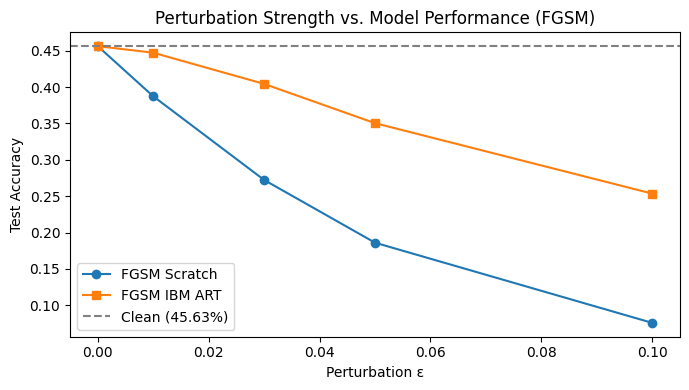

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(results["epsilon"], results["scratch"], "o-", label="FGSM Scratch")
plt.plot(results["epsilon"], results["art"],     "s-", label="FGSM IBM ART")
plt.axhline(clean_acc, linestyle="--", color="gray", label=f"Clean ({clean_acc:.2%})")
plt.xlabel("Perturbation ε")
plt.ylabel("Test Accuracy")
plt.title("Perturbation Strength vs. Model Performance (FGSM)")
plt.legend()
plt.tight_layout()
plt.savefig("fgsm_eps_vs_acc.png", dpi=120)
wandb.log({"eps_vs_acc": wandb.Image("fgsm_eps_vs_acc.png")})
plt.show()

## 12. Qualitative Comparison: Original vs Adversarial

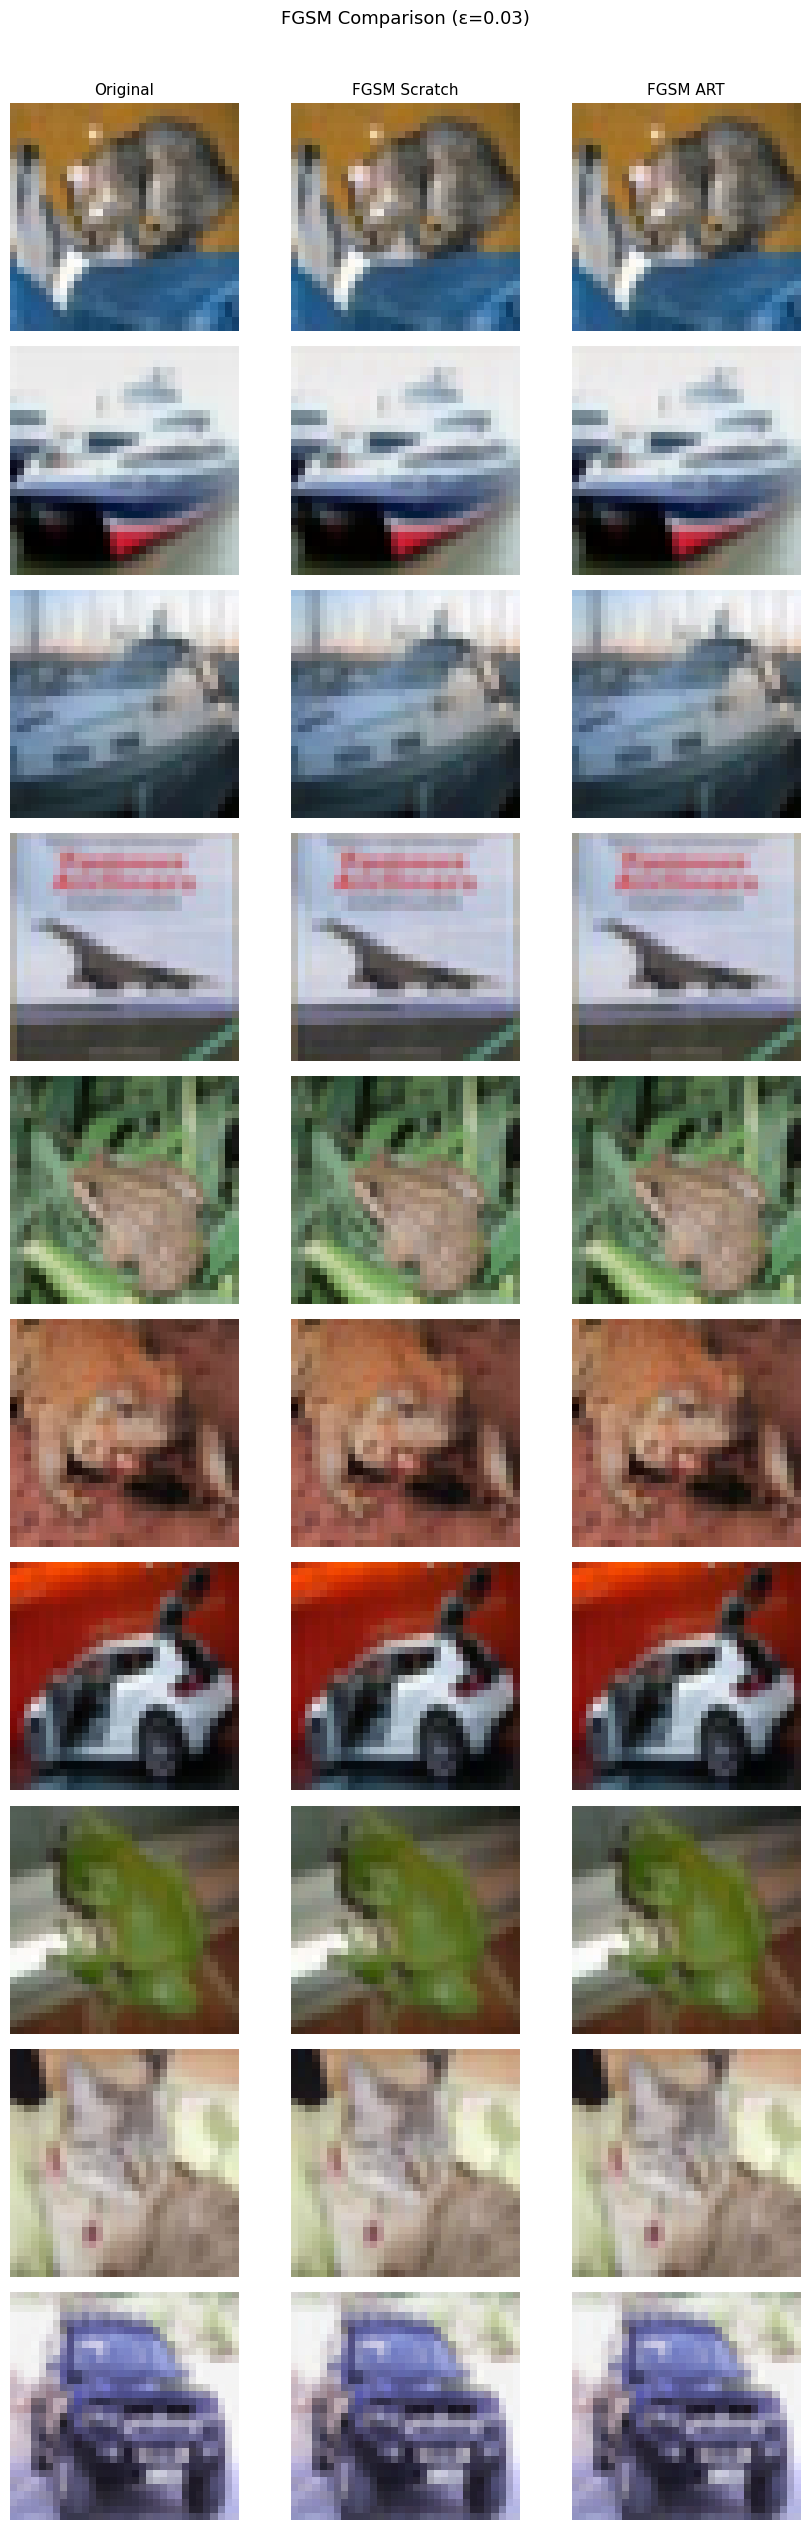

In [31]:
inv_transform = transforms.Normalize(
    mean=[-m / s for m, s in zip(MEAN, STD)],
    std=[1.0 / s for s in STD],
)
to_img = lambda t: np.clip(inv_transform(t).permute(1, 2, 0).numpy(), 0, 1)

def show_comparison(epsilon=0.03, n=10):
    inputs, labels = next(iter(testloader))
    inputs, labels = inputs[:n], labels[:n]

    adv_scratch = fgsm_scratch(model, inputs, labels, epsilon).cpu()
    adv_art     = torch.tensor(
        FastGradientMethod(estimator=art_clf, eps=epsilon).generate(inputs.numpy())
    )

    fig, axes = plt.subplots(n, 3, figsize=(9, n * 2.5))
    axes[0][0].set_title("Original",     fontsize=11)
    axes[0][1].set_title("FGSM Scratch", fontsize=11)
    axes[0][2].set_title("FGSM ART",     fontsize=11)
    for i in range(n):
        axes[i][0].imshow(to_img(inputs[i]))
        axes[i][1].imshow(to_img(adv_scratch[i]))
        axes[i][2].imshow(to_img(adv_art[i]))
        for ax in axes[i]:
            ax.axis("off")
        axes[i][0].set_ylabel(CLASSES[labels[i]], fontsize=9)
    plt.suptitle(f"FGSM Comparison (ε={epsilon})", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("fgsm_comparison.png", dpi=100, bbox_inches="tight")
    wandb.log({"FGSM_comparison": wandb.Image("fgsm_comparison.png")})
    plt.show()

show_comparison(epsilon=0.03)

---
# Adversarial Detection Model
### ResNet-34 binary classifier — clean vs adversarial (PGD & BIM)

## 13. Prepare Source Data for Adversarial Generation

In [32]:
# Pre-load entire test set as tensors for efficient ART input
test_all   = torch.stack([testset[i][0] for i in range(len(testset))])
labels_all = torch.tensor([testset[i][1] for i in range(len(testset))])

# First 5000 → adversarial source | Last 5000 → held-out clean for detector
x_adv_src = test_all[:5000].numpy()
x_clean   = test_all[5000:]

print(f"Adversarial source: {x_adv_src.shape}")
print(f"Held-out clean:     {x_clean.shape}")

Adversarial source: (5000, 3, 32, 32)
Held-out clean:     torch.Size([5000, 3, 32, 32])


## 14. Generate Adversarial Images (PGD & BIM)

In [33]:
def generate_adversarials(art_clf, attack_name="pgd"):
    print(f"Generating {attack_name.upper()} adversarials …")
    if attack_name == "pgd":
        attack = ProjectedGradientDescent(
            estimator=art_clf, eps=0.03, eps_step=0.007, max_iter=10, targeted=False
        )
    else:  # bim
        attack = BasicIterativeMethod(
            estimator=art_clf, eps=0.03, eps_step=0.007, max_iter=10
        )
    adv_list = []
    bs = 256
    for start in range(0, len(x_adv_src), bs):
        adv_list.append(attack.generate(x=x_adv_src[start:start + bs]))
        print(f"  {min(start + bs, len(x_adv_src))}/{len(x_adv_src)}", end="\r")
    print()
    return np.concatenate(adv_list, axis=0)


adv_cache = {}
for atk in ["pgd", "bim"]:
    cache_path = f"adv_{atk}.npy"
    if os.path.exists(cache_path):
        print(f"Loading cached {atk.upper()} adversarials …")
        adv_cache[atk] = np.load(cache_path)
    else:
        adv_cache[atk] = generate_adversarials(art_clf, atk)
        np.save(cache_path, adv_cache[atk])
    print(f"{atk.upper()} adversarials shape: {adv_cache[atk].shape}")

Generating PGD adversarials …


PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

...

PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/8 [00:00<?, ?it/s]

PGD - Batches:   0%|          | 0/5 [00:00<?, ?it/s]

  5000/5000
BIM adversarials shape: (5000, 3, 32, 32)


## 15. Log 10 Clean + Adversarial Samples to WandB

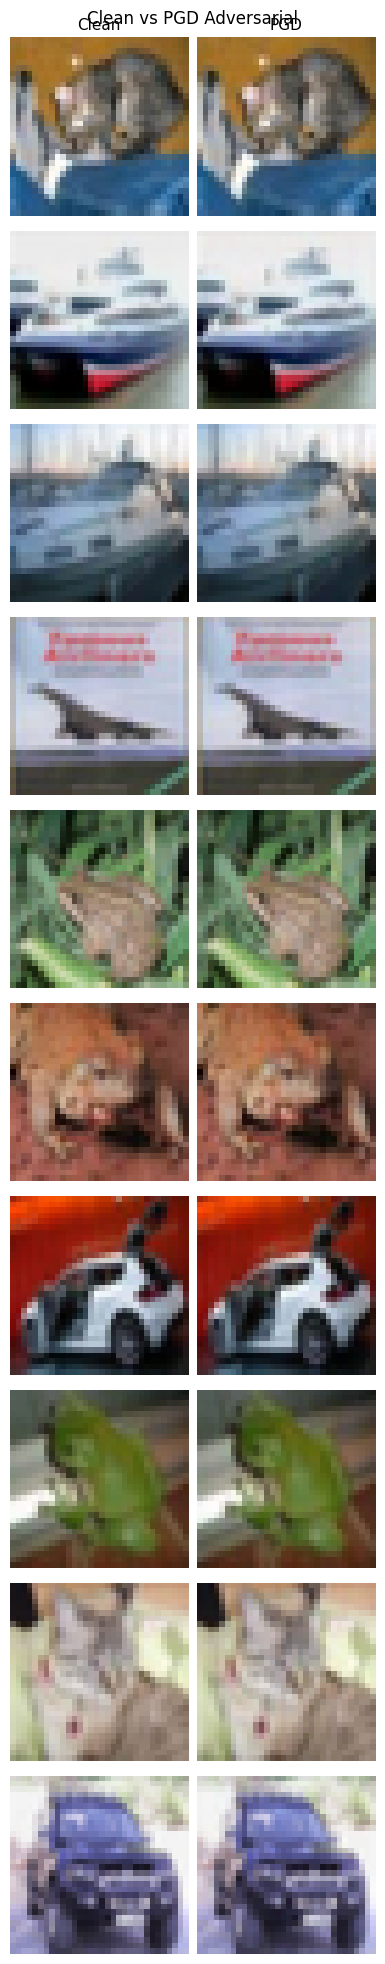

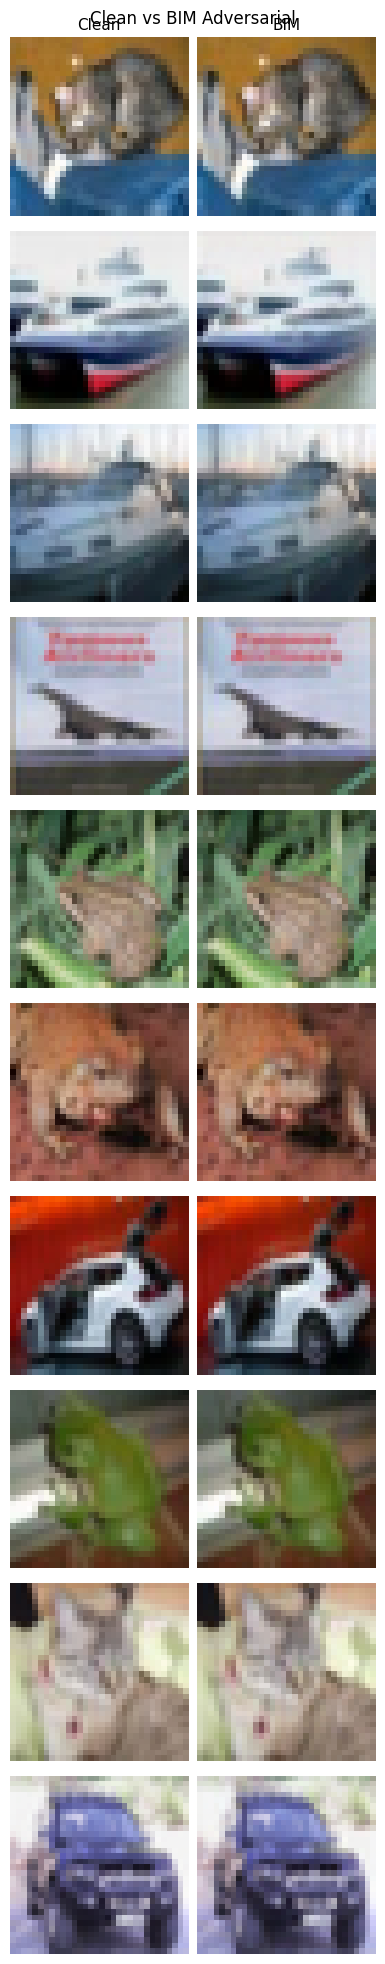

In [34]:
def log_and_show_samples(x_adv_np, attack_name, n=10):
    fig, axes = plt.subplots(n, 2, figsize=(4, n * 2))
    axes[0][0].set_title("Clean",             fontsize=11)
    axes[0][1].set_title(attack_name.upper(), fontsize=11)

    clean_wb, adv_wb = [], []
    for i in range(n):
        c_img = to_img(test_all[i])
        a_img = np.clip(inv_transform(torch.tensor(x_adv_np[i])).permute(1, 2, 0).numpy(), 0, 1)
        axes[i][0].imshow(c_img);  axes[i][0].axis("off")
        axes[i][1].imshow(a_img);  axes[i][1].axis("off")
        clean_wb.append(wandb.Image(c_img, caption=f"Clean {i}"))
        adv_wb.append(wandb.Image(a_img,   caption=f"{attack_name} Adv {i}"))

    plt.suptitle(f"Clean vs {attack_name.upper()} Adversarial", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"comparison_{attack_name}.png", dpi=100, bbox_inches="tight")
    wandb.log({f"clean_samples_{attack_name}": clean_wb,
               f"adv_samples_{attack_name}": adv_wb})
    plt.show()

for atk in ["pgd", "bim"]:
    log_and_show_samples(adv_cache[atk], atk)

## 16. Build Detector Datasets

In [35]:
def make_detector_datasets(x_adv_np, n_train=4000, n_val=1000):
    """Label 0 = clean, Label 1 = adversarial."""
    x_adv = torch.tensor(x_adv_np, dtype=torch.float32)

    x_tr = torch.cat([test_all[:n_train],        x_adv[:n_train]])
    y_tr = torch.cat([torch.zeros(n_train), torch.ones(n_train)]).long()

    x_va = torch.cat([x_clean[:n_val],           x_adv[n_train:n_train + n_val]])
    y_va = torch.cat([torch.zeros(n_val),   torch.ones(n_val)]).long()

    tr_loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=64, shuffle=True)
    va_loader = DataLoader(TensorDataset(x_va, y_va), batch_size=64, shuffle=False)
    return tr_loader, va_loader

print("Detector dataset builder ready.")

Detector dataset builder ready.


## 17. Detector Model — ResNet-34 (Binary)

In [36]:
def get_detector():
    det = models.resnet34(weights=None)
    det.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    det.maxpool = nn.Identity()
    det.fc      = nn.Linear(512, 2)   # binary: clean vs adversarial
    return det.to(DEVICE)

d = get_detector()
print(f"ResNet-34 Detector parameters: {sum(p.numel() for p in d.parameters()):,}")
del d

ResNet-34 Detector parameters: 21,278,018


## 18. Train & Evaluate Detector

In [37]:
DET_EPOCHS = 15
DET_LR     = 1e-3

def eval_detector(det, loader, criterion):
    det.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y      = x.to(DEVICE), y.to(DEVICE)
            out       = det(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct  += out.argmax(1).eq(y).sum().item()
            total    += y.size(0)
    return loss_sum / total, correct / total


def train_detector(tr_loader, va_loader, attack_name):
    det       = get_detector()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(det.parameters(), lr=DET_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=DET_EPOCHS)

    best_acc  = 0.0
    best_path = f"detector_resnet34_{attack_name}.pth"
    history   = {"tr_loss": [], "tr_acc": [], "va_loss": [], "va_acc": []}

    for epoch in range(1, DET_EPOCHS + 1):
        det.train()
        tr_loss, tr_correct, tr_total = 0.0, 0, 0
        for x, y in tr_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = det(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            tr_loss    += loss.item() * x.size(0)
            tr_correct += out.argmax(1).eq(y).sum().item()
            tr_total   += y.size(0)
        scheduler.step()

        va_loss, va_acc = eval_detector(det, va_loader, criterion)
        tr_acc = tr_correct / tr_total

        history["tr_loss"].append(tr_loss / tr_total)
        history["tr_acc"].append(tr_acc)
        history["va_loss"].append(va_loss)
        history["va_acc"].append(va_acc)

        print(f"[{attack_name.upper()}] Epoch {epoch:02d} | "
              f"Train Loss: {tr_loss/tr_total:.4f} | Train Acc: {tr_acc:.4f} | "
              f"Val Loss: {va_loss:.4f} | Val Acc: {va_acc:.4f}")
        wandb.log({
            f"{attack_name}_det_epoch":   epoch,
            f"{attack_name}_det_tr_loss": tr_loss / tr_total,
            f"{attack_name}_det_tr_acc":  tr_acc,
            f"{attack_name}_det_va_loss": va_loss,
            f"{attack_name}_det_va_acc":  va_acc,
        })

        if va_acc > best_acc:
            best_acc = va_acc
            torch.save(det.state_dict(), best_path)

    print(f"\n[{attack_name.upper()}] Best Detection Accuracy: {best_acc:.4f}")
    det.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return det, best_acc, history

print("Detector training functions defined.")

Detector training functions defined.


## 19. Run Detectors for PGD and BIM

In [38]:
det_results  = {}
det_history  = {}
det_models   = {}

for atk in ["pgd", "bim"]:
    print(f"\n{'='*55}")
    print(f"  Training Detector for {atk.upper()} attack")
    print(f"{'='*55}")
    tr_l, va_l   = make_detector_datasets(adv_cache[atk])
    det, acc, hist = train_detector(tr_l, va_l, atk)
    det_results[atk]  = acc
    det_history[atk]  = hist
    det_models[atk]   = det


  Training Detector for PGD attack
[PGD] Epoch 01 | Train Loss: 0.7457 | Train Acc: 0.4904 | Val Loss: 0.7092 | Val Acc: 0.5060
[PGD] Epoch 02 | Train Loss: 0.7040 | Train Acc: 0.5002 | Val Loss: 0.7076 | Val Acc: 0.4985
[PGD] Epoch 03 | Train Loss: 0.7015 | Train Acc: 0.5035 | Val Loss: 0.6965 | Val Acc: 0.5005
[PGD] Epoch 04 | Train Loss: 0.6998 | Train Acc: 0.4984 | Val Loss: 0.6983 | Val Acc: 0.5040
[PGD] Epoch 05 | Train Loss: 0.7012 | Train Acc: 0.4918 | Val Loss: 0.7018 | Val Acc: 0.5020
[PGD] Epoch 06 | Train Loss: 0.7000 | Train Acc: 0.4955 | Val Loss: 0.7113 | Val Acc: 0.4970
[PGD] Epoch 07 | Train Loss: 0.6983 | Train Acc: 0.4960 | Val Loss: 0.6969 | Val Acc: 0.4930
[PGD] Epoch 08 | Train Loss: 0.6953 | Train Acc: 0.4884 | Val Loss: 0.6921 | Val Acc: 0.5055
[PGD] Epoch 09 | Train Loss: 0.6964 | Train Acc: 0.4908 | Val Loss: 0.7021 | Val Acc: 0.4980
[PGD] Epoch 10 | Train Loss: 0.6966 | Train Acc: 0.4959 | Val Loss: 0.6954 | Val Acc: 0.4910
[PGD] Epoch 11 | Train Loss: 0.696

## 20. Plot Detector Training Curves

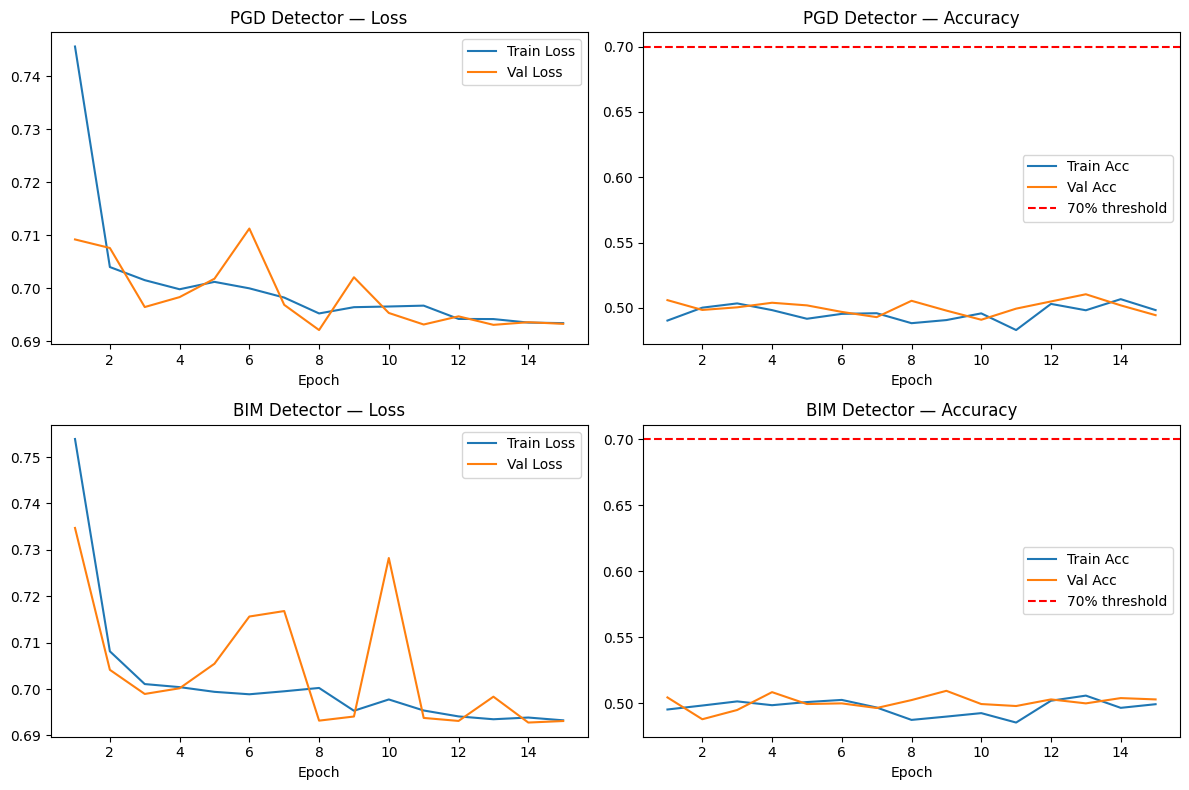

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, atk in enumerate(["pgd", "bim"]):
    h = det_history[atk]
    epochs = range(1, len(h["tr_loss"]) + 1)

    axes[row][0].plot(epochs, h["tr_loss"], label="Train Loss")
    axes[row][0].plot(epochs, h["va_loss"], label="Val Loss")
    axes[row][0].set_title(f"{atk.upper()} Detector — Loss")
    axes[row][0].set_xlabel("Epoch"); axes[row][0].legend()

    axes[row][1].plot(epochs, h["tr_acc"], label="Train Acc")
    axes[row][1].plot(epochs, h["va_acc"], label="Val Acc")
    axes[row][1].axhline(0.70, linestyle="--", color="red", label="70% threshold")
    axes[row][1].set_title(f"{atk.upper()} Detector — Accuracy")
    axes[row][1].set_xlabel("Epoch"); axes[row][1].legend()

plt.tight_layout()
plt.savefig("detector_training_curves.png", dpi=120)
wandb.log({"detector_training_curves": wandb.Image("detector_training_curves.png")})
plt.show()

## 21. Final Summary

In [40]:
print("\n" + "="*50)
print("  FINAL RESULTS SUMMARY")
print("="*50)
print(f"  Clean Test Accuracy (ResNet18):  {clean_acc:.4f} ({clean_acc*100:.2f}%)")
print()
print(f"  {'ε':>5} | {'FGSM Scratch':>13} | {'FGSM ART':>10}")
print("  " + "-"*36)
for i, eps in enumerate(results["epsilon"]):
    print(f"  {eps:>5.3f} |     {results['scratch'][i]:.4f}    |   {results['art'][i]:.4f}")
print()
print(f"  {'Attack':>6} | {'Detection Acc':>14} | {'Pass (≥70%)?':>12}")
print("  " + "-"*38)
for atk, acc in det_results.items():
    status = "✓ PASS" if acc >= 0.70 else "✗ FAIL"
    print(f"  {atk.upper():>6} |     {acc:.4f}       |   {status}")
print("="*50)

wandb.log({
    "clean_accuracy": clean_acc,
    "pgd_best_detection_acc": det_results.get("pgd", 0),
    "bim_best_detection_acc": det_results.get("bim", 0),
})
wandb.finish()
print("\nWandB run finished.")


  FINAL RESULTS SUMMARY
  Clean Test Accuracy (ResNet18):  0.4563 (45.63%)

      ε |  FGSM Scratch |   FGSM ART
  ------------------------------------
  0.000 |     0.4563    |   0.4563
  0.010 |     0.3874    |   0.4473
  0.030 |     0.2723    |   0.4044
  0.050 |     0.1860    |   0.3504
  0.100 |     0.0757    |   0.2535

  Attack |  Detection Acc | Pass (≥70%)?
  --------------------------------------
     PGD |     0.5105       |   ✗ FAIL
     BIM |     0.5095       |   ✗ FAIL


acc_fgsm_art,██▆▄▁
acc_fgsm_scratch,█▇▅▃▁
bim_best_detection_acc,▁
bim_det_epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
bim_det_tr_acc,▄▅▆▆▆▇▅▂▃▃▁▇█▅▆
bim_det_tr_loss,█▃▂▂▂▂▂▂▁▂▁▁▁▁▁
bim_det_va_acc,▆▁▃█▅▅▄▆█▅▄▆▅▆▆
bim_det_va_loss,█▃▂▂▃▅▅▁▁▇▁▁▂▁▁
clean_accuracy,▁
epsilon,▁▂▃▅█
+6,...



WandB run finished.
